# 1. Instalación de librerías y configuración inicial

In [1]:
import glob
import logging
import os
import random
import shutil
import sys
import tarfile
import yaml

from collections import Counter, defaultdict
import cv2
import h5py
from huggingface_hub import hf_hub_download
from IPython import display
import json
import matplotlib.pyplot as plt
import numpy as np
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
)
import pandas as pd
from PIL import Image
import scipy.io
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
import torch
from torchvision.datasets import ImageFolder
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm, trange

In [2]:
def set_global_seed(seed: int = 42):
    """
    Fija todas las semillas necesarias para asegurar reproducibilidad
    en experimentos.
    """
    # Python y entorno
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # CuDNN (para asegurar resultados deterministas en GPU)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Semillas fijadas en {seed}")

In [3]:
seed = 42
set_global_seed(seed)

Semillas fijadas en 42


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU disponible:", torch.cuda.is_available())
print("Nombre de la GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Ninguna")

GPU disponible: True
Nombre de la GPU: NVIDIA GeForce RTX 5060 Ti


# 2. Carga de _dataset_ propio para _fine-tuning_

In [5]:
current_workspace = os.getcwd()
DATA_ROOT_CLASSIFICATION = os.path.abspath(os.path.join(current_workspace,
                                                     "..", "data",
                                                     "data_modelo_clasificacion"))
TARGET_DIR = os.path.join(DATA_ROOT_CLASSIFICATION, "digits_resnet")
EXTRACTED_DATA_DIR = os.path.join(TARGET_DIR, "data")

os.makedirs(TARGET_DIR, exist_ok=True)
os.makedirs(EXTRACTED_DATA_DIR, exist_ok=True)

# Descarga de los archivos desde el dataset
repo_id = "U20212419/digits"

# Descargar data.tar
data_tar_path = hf_hub_download(repo_id=repo_id,
                                filename="data.tar",
                                repo_type="dataset")

# Descargar train.txt
train_txt_path = hf_hub_download(repo_id=repo_id,
                                 filename="train.txt",
                                 repo_type="dataset")

# Descargar data.yaml
data_yaml_path = hf_hub_download(repo_id=repo_id,
                                 filename="data.yaml",
                                 repo_type="dataset")

print("Archivos descargados exitosamente.")

# Extraer data.tar
print("\nExtrayendo data.tar en '{TARGET_DIR}'...")
with tarfile.open(data_tar_path, "r") as tar_ref:
    tar_ref.extractall(TARGET_DIR, filter="data")

print("Subcarpetas encontradas:", os.listdir(EXTRACTED_DATA_DIR))

# Cargar rutas de imágenes desde train.txt
with open(train_txt_path, "r") as f:
    image_paths = [line.strip() for line in f.readlines()]

print(f"Total de imágenes en train.txt: {len(image_paths)}")

# Cargar data.yaml
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)
data_yaml["path"] = EXTRACTED_DATA_DIR
data_yaml["train"] = "images/train"
data_yaml["val"] = "images/val"
data_yaml["test"] = "images/test"

print("\ndata.yaml cargado:")
print("path:", data_yaml["path"])
print("train:", data_yaml["train"])
print("val:", data_yaml["val"])
print("test:", data_yaml["test"])
print("classes:", data_yaml["names"])

# Guardar el YAML en la carpeta data
yaml_save_path = os.path.join(EXTRACTED_DATA_DIR, 'data.yaml')
with open(yaml_save_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

# Verificar existencia de archivos
missing = []
for p in image_paths:
    # Limpiar el prefijo de train.txt para obtener la ruta relativa correcta
    clean_p = p.replace('./data/', '').replace('data/', '')
    full_path = os.path.join(EXTRACTED_DATA_DIR, clean_p)

    if not os.path.exists(full_path):
        missing.append(full_path)

if missing:
    print(f"{len(missing)} archivos no encontrados.")
else:
    print("Todas las imágenes existen.")

Archivos descargados exitosamente.

Extrayendo data.tar en '{TARGET_DIR}'...
Subcarpetas encontradas: ['images', 'labels']
Total de imágenes en train.txt: 1110

data.yaml cargado:
path: c:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_clasificacion\digits_resnet\data
train: images/train
val: images/val
test: images/test
classes: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '.'}
Todas las imágenes existen.


In [6]:
# Estructura de carpetas
def ensure_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

root_cropped = os.path.join(TARGET_DIR, "data_cropped")
train_out = os.path.join(root_cropped, "train")
val_out = os.path.join(root_cropped, "val")
test_out = os.path.join(root_cropped, "test")

num_classes = len(data_yaml["names"])
for i in range(num_classes):
    ensure_dir(os.path.join(train_out, str(i)))
    ensure_dir(os.path.join(val_out, str(i)))
    ensure_dir(os.path.join(test_out, str(i)))

Se recortan los _bounding boxes_ de las imágenes, utilizando las coordenadas normalizadas que provienen de las etiquetas del _dataset_, para obtener los caracteres individuales.

In [7]:
def crop_bounding_box(image, points):
    """Recorta una caja rectangular dada por 4 puntos (x,y)."""
    h, w = image.shape[:2]
    pts = np.array(points, dtype=np.float32).reshape(4, 2)

    # Convertir coordenadas normalizadas a píxeles reales
    pts[:, 0] = pts[:, 0] * w
    pts[:, 1] = pts[:, 1] * h

    x_min = int(np.min(pts[:, 0]))
    x_max = int(np.max(pts[:, 0]))
    y_min = int(np.min(pts[:, 1]))
    y_max = int(np.max(pts[:, 1]))

    # Verificar límites válidos
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(w, x_max)
    y_max = min(h, y_max)

    # Recorte
    cropped = image[y_min:y_max, x_min:x_max]

    # Evitar recortes vacíos
    if cropped.shape[0] < 2 or cropped.shape[1] < 2:
        return None

    # Redimensionar a 224x224
    cropped = cv2.resize(cropped, (224, 224))
    return cropped

In [8]:
# Recortar todas las imágenes
path_labels = os.path.join(EXTRACTED_DATA_DIR, "labels")
label_dirs = glob.glob(os.path.join(path_labels, "**", "*.*"), recursive=True)
print(f"Archivos de labels encontrados: {len(label_dirs)}")

for label_path in tqdm(label_dirs, desc="Procesando labels"):
    img_path = label_path.replace("labels",
                                  "images").rsplit(".", 1)[0] + ".jpg"
    if not os.path.exists(img_path):
        continue
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Determinar el subconjunto
    clean_label_path = label_path.replace('\\', '/')
    print(clean_label_path)
    subset = ("train" if "train/" in clean_label_path
              else "val" if "val/" in clean_label_path
              else "test")

    with open(label_path, "r") as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) != 9:
                continue
            cls = int(parts[0])
            coords = list(map(float, parts[1:]))
            cropped = crop_bounding_box(img, coords)

            if cropped is not None:
                crop_name = (f"{os.path.basename(img_path).split('.')[0]}"
                             f"_{i}.jpg")
                out_path = os.path.join(root_cropped, subset,
                                        str(cls), crop_name)
                cv2.imwrite(out_path, cropped)

print("\nRecortes almacenados en:", root_cropped)

Archivos de labels encontrados: 1110


Procesando labels:   0%|          | 3/1110 [00:00<00:46, 24.00it/s]

c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00000.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00010.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00032.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00044.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00061.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00082.txt


Procesando labels:   1%|          | 9/1110 [00:00<00:42, 25.71it/s]

c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00094.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00109.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00119.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00127.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00137.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_001_frame_00142.txt


...

c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00184.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00185.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00194.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00204.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00210.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00214.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00219.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/

Procesando labels:  99%|█████████▉| 1100/1110 [00:27<00:00, 47.55it/s]

c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00247.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00260.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00264.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00268.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00273.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00278.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00282.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/

Procesando labels: 100%|██████████| 1110/1110 [00:27<00:00, 39.92it/s]

c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00315.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00318.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00326.txt
c:/Users/Flavio/Desktop/tesis_notebooks/data/data_modelo_clasificacion/digits_resnet/data/labels/train/video_032_frame_00330.txt

Recortes almacenados en: c:\Users\Flavio\Desktop\tesis_notebooks\data\data_modelo_clasificacion\digits_resnet\data_cropped


Se realiza el _split_ del conjunto de datos en subconjuntos de entrenamiento, validación y prueba. Se asegura todas las imágenes correspondientes a cada video original se encuentren en el mismo subconjunto, para evitar la fuga de datos, pues los fotogramas de un mismo video suelen tener características muy similares (misma escritura y condiciones de grabación).

In [9]:
def split_train_val(base_dir="data_cropped/train",
                    val_ratio=0.15, test_ratio=0.15):
    """
    Divide los crops de 'base_dir' (que contiene todas las clases)
    en nuevos directorios 'val' y 'test', asegurando que todos
    los crops de un mismo video permanezcan en el mismo split.
    """
    root_dir = os.path.dirname(base_dir)
    val_root = os.path.join(root_dir, "val")
    test_root = os.path.join(root_dir, "test")

    os.makedirs(val_root, exist_ok=True)
    os.makedirs(test_root, exist_ok=True)

    # Agrupar los crops por video_key
    video_groups = defaultdict(list)

    # Buscar todos los .jpg en todas las subcarpetas de clases
    all_crops = glob.glob(os.path.join(base_dir, "**", "*.jpg"),
                          recursive=True)
    if not all_crops:
        print(f"Error: No se encontraron crops en {base_dir}")
        return

    for crop_path in all_crops:
        crop_name = os.path.basename(crop_path)
        try:
            # Formato "video_ABC_...": la llave es "video_ABC"
            key_parts = crop_name.split('_')
            video_key = f"{key_parts[0]}_{key_parts[1]}"
            video_groups[video_key].append(crop_path)
        except IndexError:
            print(f"Advertencia: {crop_name} no tiene "
                  f"el formato de video esperado.")

    print(f"Encontrados {len(all_crops)} crops de "
          f"{len(video_groups)} videos únicos.")

    # Dividir los 'video_keys'
    video_keys = list(video_groups.keys())
    random.shuffle(video_keys)

    n_videos = len(video_keys)
    n_val = int(n_videos * val_ratio)
    n_test = int(n_videos * test_ratio)
    # n_train es el resto

    # (n_val) y (n_val + n_test) son los puntos de corte
    val_keys, test_keys, train_keys = np.split(
        video_keys,
        [n_val, n_val + n_test]
    )

    print(f"División de videos: {len(train_keys)} train, "
          f"{len(val_keys)} val, {len(test_keys)} test.")

    # Función auxiliar para mover archivos
    def move_video_files(keys_list, dest_root):
        """Mueve todos los crops de una lista de keys al destino."""
        moved_count = 0
        for key in tqdm(keys_list,
                        desc=f"Moviendo a {os.path.basename(dest_root)}"):
            for src_path in video_groups[key]:
                try:
                    # Obtener la clase del nombre de la carpeta
                    class_id = os.path.basename(os.path.dirname(src_path))

                    # Crear la carpeta de destino de la clase
                    dest_cls_dir = os.path.join(dest_root, class_id)
                    os.makedirs(dest_cls_dir, exist_ok=True)

                    # Mover el archivo
                    dest_path = os.path.join(dest_cls_dir,
                                             os.path.basename(src_path))
                    shutil.move(src_path, dest_path)
                    moved_count += 1
                except Exception as e:
                    print(f"Error moviendo {src_path}: {e}")
        return moved_count

    # Ejecutar el movimiento
    val_moved = move_video_files(val_keys, val_root)
    test_moved = move_video_files(test_keys, test_root)

    # Los archivos de train son los que quedan en base_dir
    train_final = len(all_crops) - val_moved - test_moved

    print("\n--- Split de Crops Completado ---")
    print(f"Crops de Train: {train_final}")
    print(f"Crops de Val: {val_moved}")
    print(f"Crops de Test: {test_moved}")

# Ejecutar el split
cropped_train_path = os.path.join(root_cropped, "train")
split_train_val(cropped_train_path,
                val_ratio=0.15,
                test_ratio=0.15)

Encontrados 18778 crops de 21 videos únicos.
División de videos: 15 train, 3 val, 3 test.


Moviendo a test: 100%|██████████| 3/3 [00:01<00:00,  2.13it/s]


--- Split de Crops Completado ---
Crops de Train: 12628
Crops de Val: 3164
Crops de Test: 2986


Se crean los DataLoader para que el modelo pueda utilizar los subconjuntos. Se aplicaron transformaciones de _data augmentation_ al subconjunto de entrenamiento, se escalaron las imágenes de todos los subconjuntos a 224x224 (tamaño de entrada por defecto de ResNet), se convirtieron las imágenes a tensores y se normalizaron en función de la media y desviación estándar del subconjunto de entrenamiento.

In [10]:
def compute_mean_std(dataset_path):
    """Hallar la media y desviación estándar de un conjunto de datos."""
    # Transformación mínima solo para leer imágenes
    tmp_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Dataset temporal
    dataset_tmp = ImageFolder(root=dataset_path,
                              transform=tmp_transform)

    # DataLoader
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(dataset_tmp, batch_size=64,
                        shuffle=False, num_workers=2,
                        generator=generator)

    # Cálculo de la media y desviación estándar
    mean = torch.zeros(3, dtype=torch.float64)
    std = torch.zeros(3, dtype=torch.float64)
    total = 0
    with torch.no_grad():
        for imgs, _ in loader:
            batch_samples = imgs.size(0)
            imgs = imgs.view(batch_samples, imgs.size(1), -1)
            mean += imgs.mean(2).sum(0).double()
            std += imgs.std(2).sum(0).double()
            total += batch_samples
    mean /= total
    std /= total
    return mean.tolist(), std.tolist()

mean, std = compute_mean_std(cropped_train_path)
print(f"Mean: {mean}, Std: {std}")

Mean: [0.6994777180403141, 0.6553159963869392, 0.6740432666909064], Std: [0.06771057322125741, 0.09574768939349029, 0.08575137099737905]


In [11]:
# Transformaciones
train_transform = transforms.Compose([
    transforms.RandomAffine(
        # Rotación
        degrees=5,
        # Traslación en los ejes x, y
        translate=(0.05, 0.05),
        # Inclinación
        shear=3,
        # Rellena con blanco
        fill=255
    ),
    # Zoom ligero
    transforms.RandomResizedCrop(224, scale=(0.85, 1.05)),
    # Cambio de brillo, contraste, saturación y tono
    transforms.ColorJitter(brightness=0.5, contrast=0.2,
                           saturation=0.3, hue=0.4),
    # Simular desenfoque
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
    ], p=0.5),  # 50% de probabilidad de aplicar esto
    # Simular pixelación (baja la escala y la vuelve a subir)
    transforms.RandomApply([
        transforms.Resize((64, 64)),
        transforms.Resize((224, 224))
    ], p=0.5),  # 50% de probabilidad de aplicar esto
    # Convertir a tensor
    transforms.ToTensor(),
    # Borrar parte de la imagen aleatoriamente
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    # Normalizar
    transforms.Normalize(mean=mean, std=std)
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [12]:
cropped_val_path = os.path.join(root_cropped, "val")
cropped_test_path = os.path.join(root_cropped, "test")

# DataLoaders
generator = torch.Generator().manual_seed(seed)
train_dataset = ImageFolder(root=cropped_train_path,
                            transform=train_transform)
val_dataset = ImageFolder(root=cropped_val_path,
                          transform=val_transform)
test_dataset = ImageFolder(root=cropped_test_path,
                           transform=test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2,
                          generator=generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2,
                        generator=generator)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2,
                         generator=generator)

print(f"Clases detectadas: {train_dataset.classes} "
      f"('10' es el separador decimal)")
print(f"Total train: {len(train_dataset)}, "
      f"val: {len(val_dataset)}, test: {len(test_dataset)}")

Clases detectadas: ['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9'] ('10' es el separador decimal)
Total train: 12628, val: 3164, test: 2986


Mostrando 8 imágenes transformadas del set de 'train'...
Clases: ['5', '5', '1', '10', '0', '5', '10', '10']


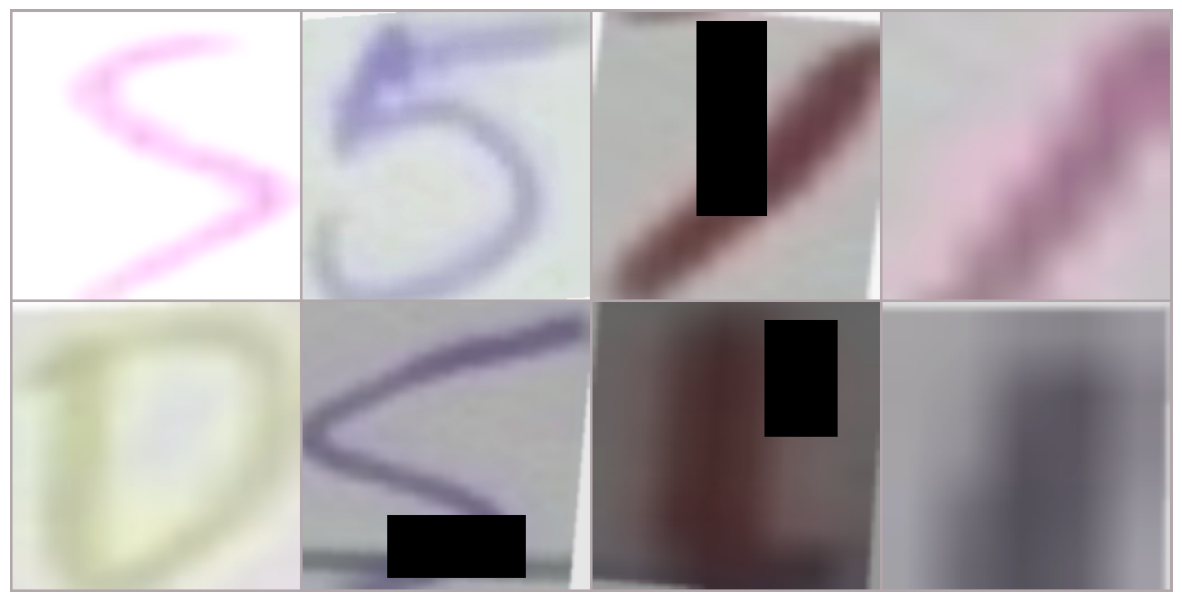

In [13]:
# Revertir la normalización
mean_tensor = torch.tensor(mean)
std_tensor = torch.tensor(std)

def unnormalize(img):
    """Revierte la normalización de ToTensor para visualización."""
    # Clonar para evitar modificar el tensor original
    img = img.clone()

    # Reorganizar las dimensiones de (C, H, W) a (H, W, C) para plt
    img = img.permute(1, 2, 0)

    # Aplicar la fórmula inversa: img = (img * std) + mean
    img = img * std_tensor + mean_tensor

    # Asegurar que los valores estén entre 0 y 1
    img = torch.clamp(img, 0, 1)
    return img

# Tomar un batch del train_loader
try:
    inputs, classes = next(iter(train_loader))
except Exception as e:
    print(f"Error al cargar el batch: {e}")
    print("Asegúrate de que 'train_loader' esté definido.")

# Crear una grilla y mostrar las imágenes
# (las primeras 8 imágenes del batch)
grid = make_grid(inputs[:8], nrow=4)
img_to_show = unnormalize(grid)

print(f"Mostrando 8 imágenes transformadas del set de 'train'...")
print(f"Clases: {[train_dataset.classes[c] for c in classes[:8]]}")

plt.figure(figsize=(15, 8))
plt.imshow(img_to_show)
plt.axis('off')
plt.show()

# 3. Optimización de hiperparámetros

Se realiza un estudio de optimización de hiperparámetros utilizando Optuna, buscando maximizar el F1-score, con el fin de no priorizar el solamente acertar las clases mayoritarias para obtener un mejor rendimiento, sino que se obligue a buscar hiperparámetros que rindan bien en todas las clases por igual. Cada intento dura 50 épocas, con _early stopping_ con paciencia de 10 épocas y _learning rate scheduler_ en función de la pérdida de validación con paciencia de 5 épocas, para evitar el sobreajuste y asegurar una convergencia correcta.

In [ ]:
def objective(trial):
    # Hiperparámetros
    lr = trial.suggest_float("lr", 1e-6, 1e-3, log=True)
    optimizer_name = "AdamW"
    dropout = trial.suggest_float("dropout", 0.0, 0.6)
    weight_decay = trial.suggest_float("weight_decay",
                                       1e-6, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    unfreeze_blocks = trial.suggest_int("unfreeze_blocks", 0, 4)

    # Imprimir hiperparámetros al inicio del trial
    logging.info(f"\nTrial {trial.number} - Hiperparámetros:")
    logging.info(f"  lr: {lr}")
    logging.info(f"  optimizer_name: {optimizer_name}")
    logging.info(f"  dropout: {dropout}")
    logging.info(f"  weight_decay: {weight_decay}")
    logging.info(f"  batch_size: {batch_size}")
    logging.info(f"  unfreeze_blocks: {unfreeze_blocks}")

    # DataLoaders
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=2,
                          generator=generator)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                            shuffle=False, num_workers=2,
                            generator=generator)

    # Modelo
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    num_features = model.fc.in_features

    # Congelar toda la red
    for param in model.parameters():
        param.requires_grad = False

    # Aplicar dropout y nueva capa final
    model.fc = nn.Sequential(  # type: ignore
        nn.Dropout(p=dropout),
        nn.Linear(num_features, 11)
    )

    # Descongelar la cabeza
    for param in model.fc.parameters():
        param.requires_grad = True

    # Descongelar N bloques desde el final
    if unfreeze_blocks > 0:
        blocks = [model.layer4, model.layer3, model.layer2, model.layer1]
        for i in range(unfreeze_blocks):
            for param in blocks[i].parameters():
                param.requires_grad = True

    model = model.to(device)

    # Criterio y optimizador
    criterion = nn.CrossEntropyLoss()
    trainable_params = filter(lambda p: p.requires_grad,
                              model.parameters())
    optimizer = optim.AdamW(trainable_params, lr=lr,
                            weight_decay=weight_decay)

    # Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                     mode='min',
                                                     factor=0.5,
                                                     patience=5)

    # Bucle de entrenamiento y validación
    n_epochs = 50
    best_val_f1 = 0.0
    patience_counter = 0
    PATIENCE_LIMIT = 10
    try:
        for epoch in trange(n_epochs, desc=f"Trial {trial.number}",
                            leave=True):
            # Entrenamiento
            model.train()
            train_correct, total_train_loss = 0, 0.0
            train_all_labels = []
            train_all_preds = []
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(1)
                train_correct += (preds == labels).sum().item()
                train_all_labels.extend(labels.cpu().numpy())
                train_all_preds.extend(preds.detach().cpu().numpy())
            train_acc = train_correct / len(train_loader.dataset)  # type: ignore
            train_loss = total_train_loss / len(train_loader.dataset)  # type: ignore
            train_f1 = f1_score(train_all_labels, train_all_preds, average='macro')

            # Validación
            model.eval()
            val_correct, total_val_loss = 0, 0.0
            val_all_labels = []
            val_all_preds = []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    total_val_loss += loss.item() * inputs.size(0)
                    preds = outputs.argmax(1)
                    val_correct += (preds == labels).sum().item()
                    val_all_labels.extend(labels.cpu().numpy())
                    val_all_preds.extend(preds.cpu().numpy())
            val_loss = total_val_loss / len(val_loader.dataset)  # type: ignore
            val_acc = val_correct / len(val_loader.dataset)  # type: ignore
            val_f1 = f1_score(val_all_labels, val_all_preds, average='macro')

            # Scheduler step
            scheduler.step(val_loss)

            # Lógica de early stopping
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
            else:
                patience_counter += 1

            logging.info(f"[Trial {trial.number}] "
                         f"Epoch {epoch+1}/{n_epochs} | "
                         f"Train Loss: {train_loss:.4f} | "
                         f"Train Acc: {train_acc:.4f} | "
                         f"Train F1: {train_f1:.4f} | "
                         f"Val Loss: {val_loss:.4f} | "
                         f"Val Acc: {val_acc:.4f} | "
                         f"Val F1: {val_f1:.4f}")

            trial.report(val_f1, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

            if patience_counter >= PATIENCE_LIMIT:
                logging.info(f"Early stopping en época {epoch+1}.")
                break

        return best_val_f1

    except optuna.TrialPruned:
        logging.info(f"Trial {trial.number} podado por pruner.")
        raise
    except RuntimeError as e:
        if 'out of memory' in str(e):
            logging.info(f"Trial {trial.number} "
                         f"podado por falta de memoria.")
            raise optuna.exceptions.TrialPruned()
        else:
            raise e

In [15]:
# Ruta donde se guardará el archivo SQLite
local_db_path = os.path.join(TARGET_DIR, "digits_resnet_optuna.db")

# Ruta donde se guardará la salida del estudio
log_path = os.path.join(TARGET_DIR, "digits_resnet_optuna.log")

# Crear logger raíz
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Limpiar cualquier handler previo
if logger.hasHandlers():
    logger.handlers.clear()

# Formato del log
log_formatter = logging.Formatter(f"%(asctime)s [%(levelname)s] "
                                  f"- %(message)s")

# Handler para archivo
file_handler = logging.FileHandler(log_path, mode='a')
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(log_formatter)

# Agregar handler al logger
logger.addHandler(file_handler)

# Callback de Optuna para forzar flush del log después de cada trial
class FlushLogCallback:
    """
    Callback de Optuna para forzar la escritura del log en disco,
    previniendo que los datos se pierdan en caso el estudio se interrumpa.
    """
    def __call__(self, study: optuna.study.Study,
                 trial: optuna.trial.FrozenTrial):
        for handler in logger.handlers:
            if isinstance(handler, logging.FileHandler):
                handler.flush()
flush_log_callback = FlushLogCallback()

In [16]:
# Cargar el estudio solo para contar los trials existentes
try:
    n_completed_trials = len(
        optuna.load_study(
            study_name="digits_resnet_tuning",
            storage=f"sqlite:///{local_db_path}"
            ).trials
        )
except KeyError:
    n_completed_trials = 0

# Sampler con semilla que depende del número de trials existentes
# Esto asegura una secuencia de sugerencias continua y reproducible
sampler = optuna.samplers.TPESampler(seed=seed + n_completed_trials)

# Pruner para cortar trials malos
pruner = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2)

# Crear el estudio
study = optuna.create_study(
    study_name="digits_resnet_tuning",
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    storage=f"sqlite:///{local_db_path}",  # Archivo local de persistencia
    load_if_exists=True
)

logging.info(f"Dirección: {study.direction.name}")

logging.info(f"Reanudando estudio. "
             f"Se han completado {n_completed_trials} trials.")
logging.info(f"El sampler se ha inicializado con la semilla "
             f"{seed + n_completed_trials}")

optuna.logging.set_verbosity(optuna.logging.WARNING)

[I 2026-08-19 04:02:37,109] A new study created in RDB with name: digits_resnet_tuning


2026-08-19 04:02:37,111 [INFO] - Dirección: MAXIMIZE
2026-08-19 04:02:37,111 [INFO] - Reanudando estudio. Se han completado 0 trials.
2026-08-19 04:02:37,113 [INFO] - El sampler se ha inicializado con la semilla 42


In [ ]:
# Ejecutar la optimización
try:
    study.optimize(
        objective,  # type: ignore
        n_trials=50,
        timeout=None,
        show_progress_bar=True,
        callbacks=[flush_log_callback]
    )
finally:
    # Mostrar mejores resultados
    try:
        best_trial = study.best_trial
        logging.info(f'\n=== MEJORES RESULTADOS ===')
        logging.info(f"Mejor trial: Trial {best_trial.number}")
        logging.info(f"F1-Score: {best_trial.value:.4f}")
        logging.info("Hiperparámetros:")
        for k, v in best_trial.params.items():
            logging.info(f"  {k}: {v}")
    except ValueError:
        logging.warning(f"El estudio finalizó sin trials completados "
                        f"exitosamente. No se puede mostrar un "
                        f"'mejor trial'.")

    logging.shutdown()
    print("Proceso finalizado. Log guardado y cerrado correctamente.")

Proceso finalizado. Log guardado y cerrado correctamente.


In [18]:
# Cargar el estudio desde el archivo SQLite
study = optuna.load_study(
    study_name="digits_resnet_tuning",
    storage=f"sqlite:///{local_db_path}"
)

In [19]:
# Mostrar los mejores resultados
print("\n=== MEJORES RESULTADOS ===")
try:
    best_trial = study.best_trial
    print(f"Mejor trial: Trial {best_trial.number}")
    print(f"F1-Score: {best_trial.value:.4f}")
    print("Hiperparámetros:")
    for k, v in best_trial.params.items():
        print(f"  {k}: {v}")
except ValueError:
    print("El estudio finalizó sin trials completados exitosamente. "
          "No se puede mostrar un 'mejor trial'.")


=== MEJORES RESULTADOS ===
Mejor trial: Trial 12
F1-Score: 0.9963
Hiperparámetros:
  lr: 0.00014293584268844557
  dropout: 0.1489659267560571
  weight_decay: 0.07378287058816868
  batch_size: 128
  unfreeze_blocks: 3


In [8]:
# Visualización a lo largo del estudio
plot_optimization_history(study).show()
plot_param_importances(study).show()

In [9]:
# Descargar gráficos de optuna
fig1 = plot_optimization_history(study)
os.makedirs(os.path.join(TARGET_DIR, "plots"), exist_ok=True)
opt_history_plot = os.path.join(TARGET_DIR, "plots", "optuna_optimization_history.svg")
fig1.write_image(opt_history_plot)
fig2 = plot_param_importances(study)
param_importances_plot = os.path.join(TARGET_DIR, "plots", "optuna_param_importances.svg")
fig2.write_image(param_importances_plot)

Todos los intentos, a excepción del Trial 1 y 2, lograron un valor alto de exactitud de validación mayor a 0.98 y el mejor resultado se logró en el Trial 12, con un F1-score de 0.9963.

El hiperparámetro que tuvo la mayor importancia durante el estudio de optimización fue la cantidad de capas descongeladas (_unfreeze_blocks_); el valor elegido fue 3, posiblemente porque la tarea de clasificación de dígitos fue suficientemente diferente de ImageNet para el modelo y requirió un ajuste profundo en los mapas de características.

En cuanto a la regularización, el _dropout_ y el _weight decay_ tuvieron pesos similares y obtuvieron los siguientes lugares en importancia, así que se confió en estos para prevenir el sobreajuste. Además, el valor de la _learning rate_ tuvo que ajustarse de tal modo que no se olviden los pesos prentrenados, pero que igualmente el modelo pueda aprender las características de la nueva tarea.

El _batch size_ fue el de menor importancia y el valor elegido fue 128, un tamaño de lote amplio que prioriza la estabilidad de los gradientes. Su bajo impacto en este estudio puede deberse a que la mejora del rendimiento dependió en mayor medida de la capacidad estructural de la red y de evitar el sobreajuste. Al realizar la optimización, se logró emparejar exitosamente los distintos tamaños de lote con tasas de aprendizaje que compensaban la dinámica de los gradientes, permitiendo que el modelo converja de manera estable sin importar mucho el tamaño de lote elegido.

# 4. _Fine-tuning_

Utilizando los hiperparámetros obtenidos, se realiza un _fine-tuning_ final con el fin de ver si se pueden mejorar los resultados. Este entrenamiento se realiza por 100 épocas, _early stopping_ con paciencia de 20 épocas y el _learning rate scheduler_ con paciencia de 5 épocas. El modo de entrenamiento es similar al de la función objetivo utilizada para la optimización de hiperparámetros.

In [20]:
# Cargar el estudio final luego de la optimización de hiperparámetros
final_study = optuna.load_study(
    study_name="digits_resnet_tuning",
    sampler=sampler,
    pruner=pruner,
    storage=f"sqlite:///{local_db_path}",
)

best_params = final_study.best_trial.params
best_params

{'lr': 0.00014293584268844557,
 'dropout': 0.1489659267560571,
 'weight_decay': 0.07378287058816868,
 'batch_size': 128,
 'unfreeze_blocks': 3}

In [21]:
# Limpiar logger anterior
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Ruta en Drive donde se guardará la salida del entrenamiento final
final_log_path = (os.path.join(TARGET_DIR, "digits_resnet_final.log"))

# Crear logger
logger_final = logging.getLogger("final_training")
logger_final.setLevel(logging.INFO)

# Limpiar cualquier handler previo
if logger_final.hasHandlers():
    logger_final.handlers.clear()

# Formato del log
log_formatter = logging.Formatter(f"%(asctime)s [%(levelname)s] "
                                  f"- %(message)s")

# Handler para archivo
os.makedirs(os.path.dirname(final_log_path), exist_ok=True)
file_handler = logging.FileHandler(final_log_path, mode='a')
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(log_formatter)

# Agregar handler al logger
logger_final.addHandler(file_handler)

In [22]:
# DataLoaders
generator = torch.Generator().manual_seed(seed)
train_loader = DataLoader(train_dataset,
                          batch_size=best_params.get("batch_size"),
                          shuffle=True, num_workers=2,
                          generator=generator)
val_loader = DataLoader(val_dataset,
                        batch_size=best_params.get("batch_size"),
                        shuffle=False, num_workers=2,
                        generator=generator)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features

# Congelar toda la red
for param in model.parameters():
    param.requires_grad = False

# Aplicar dropout y nueva capa final
model.fc = nn.Sequential(  # type: ignore
    nn.Dropout(p=best_params.get("dropout")),  # type: ignore
    nn.Linear(num_features, 11)
)

# Descongelar la cabeza
for param in model.fc.parameters():
    param.requires_grad = True

# Descongelar N bloques desde el final
if best_params.get("unfreeze_blocks") > 0:  # type: ignore
    blocks = [model.layer4, model.layer3, model.layer2, model.layer1]
    for i in range(best_params.get("unfreeze_blocks")):  # type: ignore
        for param in blocks[i].parameters():
            param.requires_grad = True

model = model.to(device)

In [24]:
# Criterio y optimizador
criterion = nn.CrossEntropyLoss()
trainable_params = filter(lambda p: p.requires_grad,
                          model.parameters())
optimizer = optim.AdamW(trainable_params, lr=best_params.get("lr"),  # type: ignore
                        weight_decay=best_params.get("weight_decay"))  # type: ignore

In [25]:
# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 mode='min',
                                                 factor=0.5,
                                                 patience=5)

In [26]:
# Entrenamiento y validación con early stopping
n_epochs = 100
patience = 20
epochs_no_improve = 0
best_val_loss = float('inf')
best_model_path = os.path.join(TARGET_DIR, "digits_resnet_best_checkpoint.pt")
resume_path = os.path.join(TARGET_DIR, "digits_resnet_resume.pt")
metrics_path = os.path.join(TARGET_DIR, "digits_resnet_metrics.csv")

# Si existe un checkpoint previo, reanudar desde ahí
start_epoch = 1
if os.path.exists(resume_path):
    checkpoint = torch.load(resume_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    best_val_loss = checkpoint["best_val_loss"]
    epochs_no_improve = checkpoint["epochs_no_improve"]
    start_epoch = checkpoint["epoch"] + 1
    logger_final.info(f"Reanudando entrenamiento desde "
                      f"la época {start_epoch}...")
else:
    logger_final.info("Entrenamiento nuevo iniciado.")

if os.path.exists(metrics_path):
    prev_df = pd.read_csv(metrics_path)
    train_losses = prev_df["train_loss"].tolist()
    val_losses = prev_df["val_loss"].tolist()
    train_f1s = prev_df["train_f1"].tolist()
    val_f1s = prev_df["val_f1"].tolist()
    logger_final.info(f"Métricas previas cargadas.")
else:
    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []

for epoch in trange(start_epoch, n_epochs + 1,
                    desc="Entrenando", position=0):
    # Entrenamiento
    model.train()
    total_train_loss = 0.0
    train_all_labels, train_all_preds = [], []
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(1)
        train_all_labels.extend(labels.cpu().numpy())
        train_all_preds.extend(preds.detach().cpu().numpy())
    train_f1 = f1_score(train_all_labels, train_all_preds, average='macro')
    train_loss = total_train_loss / len(train_loader.dataset)  # type: ignore

    # Validación
    model.eval()
    total_val_loss = 0.0
    val_all_labels, val_all_preds = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            val_all_labels.extend(labels.cpu().numpy())
            val_all_preds.extend(preds.cpu().numpy())
    val_f1 = f1_score(val_all_labels, val_all_preds, average='macro')
    val_loss = total_val_loss / len(val_loader.dataset)  # type: ignore

    # Scheduler step
    scheduler.step(val_loss)

    # Guardar métricas
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    logger_final.info(f"Epoch {epoch}/{n_epochs} | "
                      f"Train Loss: {train_loss:.4f} | "
                      f"Train F1: {train_f1:.4f} | "
                      f"Val Loss: {val_loss:.4f} | "
                      f"Val F1: {val_f1:.4f}")

    # Guardar mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        logger_final.info("Nuevo mejor modelo guardado.")
    else:
        epochs_no_improve += 1
        logger_final.info(f"Sin mejora en "
                          f"{epochs_no_improve}/{patience} épocas.")

    # Guardar estado para reanudar si se corta
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_no_improve": epochs_no_improve
    }
    temp_path = resume_path + ".tmp"
    torch.save(checkpoint, temp_path)
    os.replace(temp_path, resume_path)
    logger_final.info(f"Estado de entrenamiento "
                      f"guardado en {resume_path}")

    # Guardar métricas en un DataFrame
    metrics_df = pd.DataFrame({
        "epoch": list(range(1, len(train_losses) + 1)),
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_f1": train_f1s,
        "val_f1": val_f1s
    })

    metrics_df.to_csv(metrics_path, index=False)
    logger_final.info(f"Métricas guardadas en {metrics_path}")

    if epochs_no_improve >= patience:
        logger_final.info("Early stopping activado.")
        break

logger_final.info("Entrenamiento finalizado.")
logging.shutdown()
print("Proceso finalizado. Log guardado y cerrado correctamente.")

Entrenando:  38%|███▊      | 38/100 [27:18<44:33, 43.13s/it]  


Proceso finalizado. Log guardado y cerrado correctamente.


In [27]:
df = pd.read_csv(metrics_path)

output_dir = os.path.join(TARGET_DIR, "plots")
os.makedirs(output_dir, exist_ok=True)

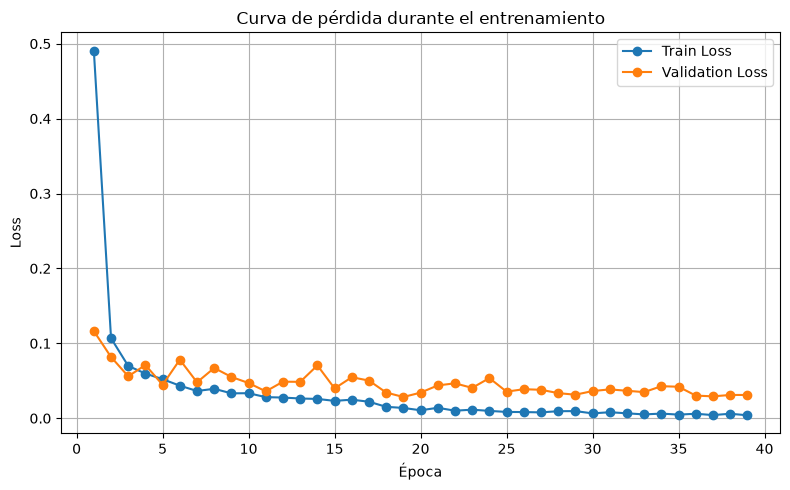

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["train_loss"],
         label="Train Loss", marker='o')
plt.plot(df["epoch"], df["val_loss"],
         label="Validation Loss", marker='o')
plt.title("Curva de pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_curve.svg"), format='svg')
plt.show()

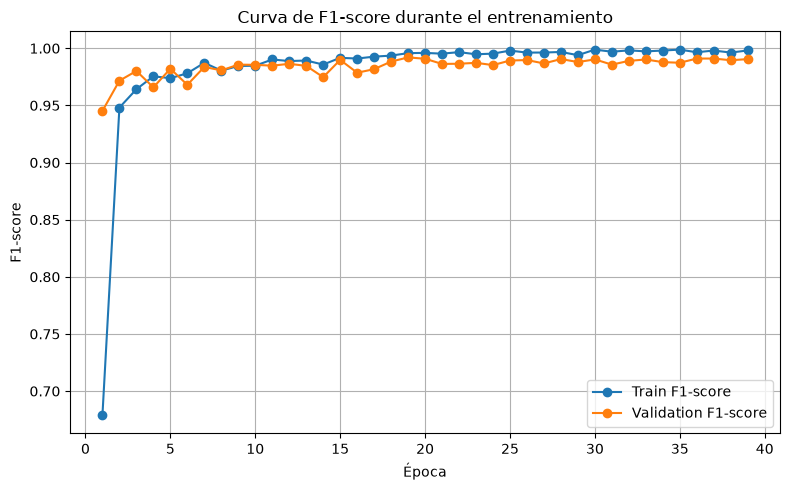

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["train_f1"],
         label="Train F1-score", marker='o')
plt.plot(df["epoch"], df["val_f1"],
         label="Validation F1-score", marker='o')
plt.title("Curva de F1-score durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "f1_curve.svg"), format='svg')
plt.show()

No se aprecian indicios de sobreajuste. La convergencia de la pérdida de validación es un ligeramente accidentada durante las primeras épocas, pero sigue disminuyendo a la par de la pérdida de entrenamiento. Se puede ver que el modelo converge rápidamente, alcanzando su mejor resultado en la época 19. A partir de ese punto, la pérdida de validaciónn se estabiliza con ligeras fluctuaciones pero sin lograr nuevas mejoras hasta que se activa el _early stopping_ en la época 39.

Los pesos del modelo final pueden ser descargados a través del siguiente enlace, desde el repositorio en Hugging Face: https://doi.org/10.57967/hf/10069.

## Evaluación final

In [31]:
# Cargar mejor modelo
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

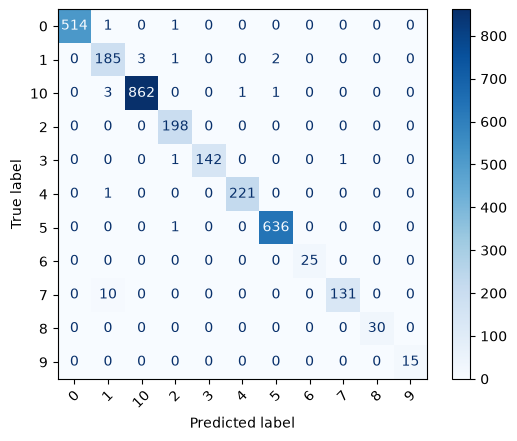


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0     1.0000    0.9961    0.9981       516
           1     0.9250    0.9686    0.9463       191
          10     0.9965    0.9942    0.9954       867
           2     0.9802    1.0000    0.9900       198
           3     1.0000    0.9861    0.9930       144
           4     0.9955    0.9955    0.9955       222
           5     0.9953    0.9984    0.9969       637
           6     1.0000    1.0000    1.0000        25
           7     0.9924    0.9291    0.9597       141
           8     1.0000    1.0000    1.0000        30
           9     1.0000    1.0000    1.0000        15

    accuracy                         0.9910      2986
   macro avg     0.9895    0.9880    0.9886      2986
weighted avg     0.9912    0.9910    0.9910      2986



In [32]:
# Matriz de confusión de las predicciones sobre el conjunto de prueba
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

class_names = test_dataset.classes

cm = confusion_matrix(all_labels, all_preds)
cm_display = ConfusionMatrixDisplay(cm,
                                    display_labels=class_names)
cm_display.plot(cmap="Blues", xticks_rotation=45)
cm_norm_path = os.path.join(output_dir,
                            "confusion_matrix_val.svg")
plt.savefig(cm_norm_path, format="svg")
plt.show()

print("\n--- Reporte de Clasificación ---")
report = classification_report(all_labels, all_preds,
                               target_names=class_names,
                               digits=4)
print(report)

Se logran excelentes resultados en el subconjunto de prueba. El F1-score obtenido (0.9886) es mayor al valor mínimo esperado (mayor a 0.95). Además, el F1-score ponderado (_weighted avg_) alcanza 0.9910, lo cual es fundamental para confirmar el éxito del modelo considerando el notorio desbalance de clases.

Analizando el F1-score macro, destaca especialmente el desempeño sobre la clase 10 (separador decimal), que alcanzó un valor de 0.9954, demostrando que el modelo aprendió a diferenciar perfectamente este trazo pequeño. Asimismo, las clases 6, 8 y 9 lograron un desempeño perfecto pese a sus pocas instancias en comparación con otras clases. El ligero descenso en el promedio macro al ponderado se debe a una dificultad específica: se ve en la matriz de confusión que el modelo ocasionalmente clasifica dígitos '7' como si fueran '1' (10 casos). Esto se refleja en la precisión de la clase 1 (0.925) y el _recall_ de la clase 7 (0.9291), los cuales son los menores valores para cada métrica respectiva. De todas formas, este es un margen de error esperable debido a la similitud visual de ambos trazos en algunas ocasiones.

La exactitud (_accuracy_) global también alcanzó un valor de 0.991, lo que respalda la solidez de las predicciones. En conclusión, el modelo cumple y supera el desempeño esperado, demostrando una excelente capacidad de generalización. El rendimiento ponderado logra un valor muy alto que sustenta el uso de este clasificador como parte de un _pipeline_ que tiene como fase anterior la detección de las _bounding boxes_ con un detector entrenado para esta tarea específica.